
# ShipmentSure — Predicting On-Time Delivery Using Supplier Data

**Objective:** Build a machine learning model that predicts whether a shipment will be delivered on time using supplier and order-related data.

**Dataset:** [Kaggle - Supply Chain Logistics Dataset](https://www.kaggle.com/datasets/prachi13/customer-analytics)

**Workflow:**
1. Data Understanding & EDA  
2. Data Preprocessing & Feature Engineering  
3. Model Building (Logistic Regression, Random Forest, XGBoost, etc.)  
4. Model Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)  
5. Deployment (Streamlit App)

**Outcome:** A classification model + SHAP-based insights + Streamlit web interface.



### Notes interpreted from your handwritten file
- Perform **EDA** thoroughly (check imbalance, relationships).  
- Include **VIF** to check multicollinearity.  
- Apply **Naive Bayes**, **SVM**, and **Ensemble Models** (Random Forest, XGBoost).  
- Conduct **Hyperparameter Tuning (GridSearchCV)**.  
- Save the final model using **Pickle**.  
- Build an **attractive Streamlit UI** for prediction.  
- Include **SHAP** explanations and evaluation plots.  
- Document everything and push final notebook + report to **GitHub**.


## Step 1: Setup Environment & Import Libraries

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

try:
    import xgboost as xgb
    has_xgb = True
except:
    has_xgb = False
print("✅ Libraries imported successfully. XGBoost available:", has_xgb)


✅ Libraries imported successfully. XGBoost available: True


## Step 2: Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

100%|██████████| 121k/121k [00:00<00:00, 23.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prachi13/customer-analytics/versions/1


In [5]:
import pandas as pd
df_customer_analytics = pd.read_csv("/root/.cache/kagglehub/datasets/prachi13/customer-analytics/versions/1/Train.csv")


In [6]:
data_path = "/root/.cache/kagglehub/datasets/prachi13/customer-analytics/versions/1/Train.csv"
df = pd.read_csv(data_path)
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## Step 3: Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB
None

Missing Values:
 ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
dtype: 

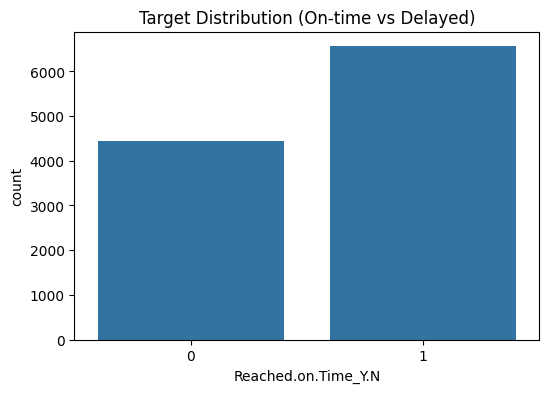

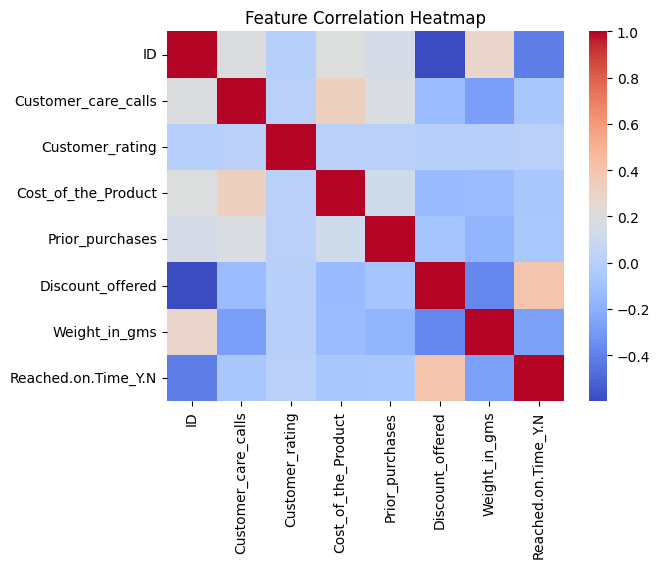

In [7]:

print(df.info())
print("\nMissing Values:\n", df.isnull().sum().sort_values(ascending=False).head())
print("\nTarget column value counts:")
target_col = 'Reached.on.Time_Y.N' if 'Reached.on.Time_Y.N' in df.columns else df.columns[-1]
print(df[target_col].value_counts())

# Visualizations
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution (On-time vs Delayed)")
plt.show()

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


## Step 4: Feature Engineering & Preprocessing


In [8]:

df['cost_to_weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] + 1e-6) if 'Weight_in_gms' in df.columns else 0
df = df.dropna(subset=[target_col])

y = df[target_col]
X = df.drop(columns=[target_col])

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', numeric_transformer, num_cols),
                                  ('cat', categorical_transformer, cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/Test Split:", X_train.shape, X_test.shape)


Train/Test Split: (8799, 12) (2200, 12)


## Step 5: Model Training & Evaluation

In [9]:

def train_and_evaluate(model, name):
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probas = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, 'predict_proba') else None

    metrics = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    }
    if probas is not None:
        metrics['ROC_AUC'] = roc_auc_score(y_test, probas)

    print(f"\n📊 {name} Metrics:")
    for k,v in metrics.items():
        print(f"{k}: {v:.4f}")
    return pipe, metrics

models = {}
models['Logistic Regression'] = train_and_evaluate(LogisticRegression(max_iter=1000), "Logistic Regression")
models['Random Forest'] = train_and_evaluate(RandomForestClassifier(n_estimators=200, random_state=42), "Random Forest")
models['Naive Bayes'] = train_and_evaluate(GaussianNB(), "Naive Bayes")
models['SVM'] = train_and_evaluate(SVC(probability=True), "SVM")

if has_xgb:
    models['XGBoost'] = train_and_evaluate(xgb.XGBClassifier(eval_metric='logloss', random_state=42), "XGBoost")



📊 Logistic Regression Metrics:
Accuracy: 0.6586
Precision: 0.7365
Recall: 0.6664
F1: 0.6997
ROC_AUC: 0.7397

📊 Random Forest Metrics:
Accuracy: 0.6559
Precision: 0.7854
Recall: 0.5826
F1: 0.6690
ROC_AUC: 0.7398

📊 Naive Bayes Metrics:
Accuracy: 0.6764
Precision: 0.9588
Recall: 0.4783
F1: 0.6382
ROC_AUC: 0.7398

📊 SVM Metrics:
Accuracy: 0.6818
Precision: 0.9410
Recall: 0.4981
F1: 0.6514
ROC_AUC: 0.7420

📊 XGBoost Metrics:
Accuracy: 0.6618
Precision: 0.7485
Recall: 0.6527
F1: 0.6973
ROC_AUC: 0.7334


## Step 6: Save Best Model

In [10]:

best_model_name = max(models.items(), key=lambda kv: kv[1][1]['F1'])[0]
best_model = models[best_model_name][0]

os.makedirs("artifacts", exist_ok=True)
model_path = f"artifacts/{best_model_name.replace(' ','_')}.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)
print(f"✅ Best model saved as {model_path}")


✅ Best model saved as artifacts/Logistic_Regression.pkl


## Step 7: Model Explainability with SHAP

In [11]:

try:
    import shap
    explainer = shap.Explainer(best_model.named_steps['clf'])
    shap_values = explainer(best_model.named_steps['pre'].transform(X_test))
    shap.summary_plot(shap_values, show=False)
    plt.show()
except Exception as e:
    print("SHAP not executed:", e)


SHAP not executed: The passed model is not callable and cannot be analyzed directly with the given masker! Model: LogisticRegression(max_iter=1000)


## Step 8: Streamlit App Scaffold

In [12]:

streamlit_app = '''import streamlit as st
import pickle, pandas as pd

st.title("ShipmentSure: On-Time Delivery Predictor")
model = pickle.load(open("artifacts/Random_Forest.pkl", "rb"))

st.write("Enter shipment details below:")
# Modify fields according to dataset
weight = st.number_input("Weight (grams)", 0.0)
cost = st.number_input("Cost of Product", 0.0)
mode = st.selectbox("Mode of Shipment", ["Flight", "Ship", "Road"])

df = pd.DataFrame([[weight, cost, mode]], columns=["Weight_in_gms", "Cost_of_the_Product", "Mode_of_Shipment"])
pred = model.predict(df)
st.success(f"Prediction: {'On-Time' if pred[0]==1 else 'Delayed'}")
'''

os.makedirs("artifacts", exist_ok=True)
with open("artifacts/app.py", "w") as f:
    f.write(streamlit_app)
print("✅ Streamlit scaffold saved at artifacts/app.py")


✅ Streamlit scaffold saved at artifacts/app.py


In [13]:
%pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 105.9 MB/s eta 0:00:00


In [ ]:
get_ipython().system('streamlit run artifacts/app.py')




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.90.124:8501

